In [1]:
############################################################
# Copyright 2019 Michael Betancourt
# Licensed under the new BSD (3-clause) license:
#
# https://opensource.org/licenses/BSD-3-Clause
############################################################

############################################################
#
# Initial setup
#
############################################################

import matplotlib.pyplot as plot
import scipy.stats as stats
import numpy
import math

light = "#DCBCBC"
light_highlight = "#C79999"
mid = "#B97C7C"
mid_highlight = "#A25050"
dark = "#8F2727"
dark_highlight = "#7C0000"
green = "#00FF00"

# To facilitate the computation of Markov chain Monte Carlo estimators 
# let's define a _Welford accumulator_ that computes empirical summaries
# of a sample in a single pass
def welford_summary(x, L = 100):
  summary = [0] * (L + 1)
  for n in range(len(x)):
    delta = x[n] - summary[0]
    summary[0] += delta / (n + 1)
    for l in range(L):
      if n > l:
        summary[l + 1] += delta * (x[n - l] - summary[0])

  norm = 1.0 / (len(x) - 1)
  for l in range(L): summary[l + 1] *= norm
  return summary

# We can then use the Welford accumulator output to compute the
# Markov chain Monte Carlo estimators and their properties
def compute_mcmc_stats(x, L = 20):
  summary = welford_summary(x, L)
  
  mean = summary[0]
  var = summary[1]
  acov = summary[1:(L + 1)]
  
  # Compute the effective sample size
  rho_hat_s = [0] * L
  rho_hat_s[1] = acov[1] / var
  
  # First we transform our autocovariances into Geyer's initial positive sequence
  max_s = 1
  for s in [ 2 * i + 1 for i in range((L - 1) // 2) ]:
    rho_hat_even = acov[s + 1] / var
    rho_hat_odd = acov[s + 2] / var;
    
    max_s = s + 2  
    
    if rho_hat_even + rho_hat_odd > 0:
      rho_hat_s[s + 1] = rho_hat_even
      rho_hat_s[s + 2] = rho_hat_odd
    else:   
      break
  
  # Then we transform this output into Geyer's initial monotone sequence
  for s in [ 2 * i + 3 for i in range((max_s - 2) // 2) ]:
    if rho_hat_s[s + 1] + rho_hat_s[s + 2] > rho_hat_s[s - 1] + rho_hat_s[s]:
      rho_hat_s[s + 1] = 0.5 * (rho_hat_s[s - 1] + rho_hat_s[s])
      rho_hat_s[s + 2] = rho_hat_s[s + 1]
  
  ess = len(x) / (1.0 + 2 * sum(rho_hat_s))
  
  return [mean, math.sqrt(var / ess), math.sqrt(var), ess]

# To generate our samples we'll use numpy's pseudo random number
# generator which needs to be seeded to achieve reproducible
# results
numpy.random.seed(seed=8675309)

# To ensure accurate results let's generate pretty large samples
N = 10000

In [2]:
############################################################
#
# One Hundred-Dimensional Gaussian Target
#
############################################################

D = 100

def target_lpdf(x):
  return - 0.5 * sum([ x_n**2 for x_n in x ]) \
         - 0.5 * len(x) * math.log(6.283185307179586)

def grad_target_lpdf(x):
  return - x

In [3]:
############################################################
#
# Random Walk Metropolis
#
############################################################

rwm_accept_prob_mean = 0
rwm_accept_prob_se = 0
rwm_ave_eff_sample_size = 0

# Optimal proposal tuning
opt_sigma = 2.5 / math.sqrt(D)

# A place to store our Markov chain
# D columns for the parameters and one extra column
# for the Metropolis acceptance probability
mcmc_samples = [[0] * (D + 1) for _ in range(N)]

# Seeding the initial state with an exact sample
# from the target distribution ensures that we
# start in the typical set and avoid having to
# worry about warmup.
for d in range(D):
  mcmc_samples[0][d] = stats.norm.rvs(0, 3)
mcmc_samples[0][D] = 1
  
for n in range(1, N):
  x0 = [ mcmc_samples[n - 1][d] for d in range(D) ] 
  xp = [ stats.norm.rvs(x0[d], opt_sigma) for d in range(D) ]

  # Compute acceptance probability
  accept_prob = 1
  if target_lpdf(xp) < target_lpdf(x0):
    accept_prob = math.exp(target_lpdf(xp) - target_lpdf(x0))
  mcmc_samples[n][D] = accept_prob

  # Apply Metropolis correction
  u = stats.uniform.rvs(0, 1)
  if accept_prob > u:
    mcmc_samples[n][0:D] = xp
  else:
    mcmc_samples[n][0:D] = x0

# Compute MCMC estimator statistics
mcmc_stats = compute_mcmc_stats([ s[D] for s in mcmc_samples])

rwm_accept_prob_mean = mcmc_stats[0]
rwm_accept_prob_se = mcmc_stats[1]

# Estimate effective sample size
eff_sample_sizes = [ compute_mcmc_stats([ s[d] for s in mcmc_samples])[3] \
                   for d in range(D) ]
rwm_ave_eff_sample_size = sum(eff_sample_sizes) / D

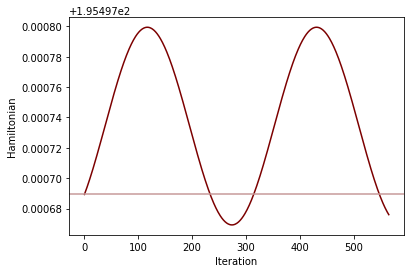

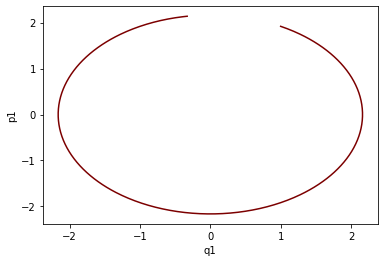

In [4]:
############################################################
#
# Hamiltonian Basics
#
############################################################

def leapfrog(q, p, epsilon):
  p += 0.5 * epsilon * grad_target_lpdf(q)
  q += epsilon * p
  p += 0.5 * epsilon * grad_target_lpdf(q)
  return [q, p]
  
def hamiltonian(q, p):
  return 0.5 * numpy.dot(p, p) - target_lpdf(q)

# Tuning
T = 1.8 * math.pi
epsilon = 0.01
L = int(math.floor(T / epsilon))

# Visualize a single trajectory
q = numpy.asarray([1.0 for _ in range(D)])
p = numpy.asarray([stats.norm.rvs(0, 1) for _ in range(D) ])

Hs = [0] * (L + 1)
q1s = [0] * (L + 1)
p1s = [0] * (L + 1)

Hs[0] = hamiltonian(q, p)
q1s[0] = q[0]
p1s[0] = p[0]

for l in range(L):
  q, p = leapfrog(q, p, epsilon)
  Hs[l + 1] = hamiltonian(q, p)
  q1s[l + 1] = q[0]
  p1s[l + 1] = p[0]
  
plot.plot(range(L + 1), Hs, color=dark_highlight)
plot.axhline(Hs[0], color=light_highlight)
plot.gca().set_xlabel("Iteration")
plot.gca().set_ylabel("Hamiltonian")
plot.show()

plot.plot(q1s, p1s, color=dark_highlight)
plot.gca().set_xlabel("q1")
plot.gca().set_ylabel("p1")
plot.show()

In [5]:
############################################################
#
# Hybrid Monte Carlo
# Hamiltonian Monte Carlo with static integration time
# considering only the final state in each numerical
# trajectory two which a Metropolis acceptance procedure
# is applied
#
############################################################

# Tuning
T = 1.8 * math.pi
epsilon = 0.6
L = int(math.floor(T / epsilon))

hybrid_accept_prob_mean = 0
hybrid_accept_prob_se = 0
hybrid_ave_eff_sample_size = 0

# A place to store our Markov chain
# D columns for the parameters and two extra columns,
# one for the Metropolis acceptance probability
# and one for divergent trajectory indicator
mcmc_samples = [[0] * (D + 2) for _ in range(N)]

# Seeding the initial state with an exact sample
# from the target distribution ensures that we
# start in the typical set and avoid having to
# worry about warmup.
for d in range(D):
  mcmc_samples[0][d] = stats.norm.rvs(0, 3)
mcmc_samples[0][D] = 1
mcmc_samples[0][D + 1] = 0
  
for n in range(1, N):
  q0 = [ mcmc_samples[n - 1][d] for d in range(D) ]
  
  q = numpy.asarray(x0)
  p = numpy.asarray([stats.norm.rvs(0, 1) for _ in range(D) ])

  H0 = hamiltonian(q, p)

  divergent = 0
  for l in range(L):
    q, p = leapfrog(q, p, epsilon)
    H = hamiltonian(q, p)
    if (H - H0 > 1000):
      divergent = 1
      break
    
  H = hamiltonian(q, -1 * p)
  
  mcmc_samples[n][D + 1] = divergent

  # Compute acceptance probability
  accept_prob = 1
  if H > H0:
    accept_prob = math.exp(H0 - H)
  mcmc_samples[n][D] = accept_prob

  # Apply Metropolis correction
  u = stats.uniform.rvs(0, 1)
  if accept_prob > u:
    mcmc_samples[n][0:D] = q
  else:
    mcmc_samples[n][0:D] = q0

# Compute MCMC estimator statistics
mcmc_stats = compute_mcmc_stats([ s[D] for s in mcmc_samples])

hybrid_accept_prob_mean = mcmc_stats[0]
hybrid_accept_prob_se = mcmc_stats[1]

# Estimate effective sample size
eff_sample_sizes = [ compute_mcmc_stats([ s[d] for s in mcmc_samples])[3] \
                   for d in range(D) ]
hybrid_ave_eff_sample_size = sum(eff_sample_sizes) / D

# Check divergences
sum([ s[D + 1] for s in mcmc_samples])

0

In [6]:
############################################################
#
# Static Multinomial Hamiltonian Monte Carlo
# Hamiltonian Monte Carlo with static integration time
# but multinomially sampling from all points within a
# numerical trajectory
#
############################################################

def log_sum_exp(x, y):
  if x > y:
    return x + math.log(1 + math.exp(y - x))
  else:
    return y + math.log(1 + math.exp(x - y))

smhmc_accept_prob_mean = 0
smhmc_accept_prob_se = 0
smhmc_ave_eff_sample_size = 0

# A place to store our Markov chain
# D columns for the parameters and one extra column
# for the Metropolis acceptance probability
mcmc_samples = [[0] * (D + 2) for _ in range(N)]

# Seeding the initial state with an exact sample
# from the target distribution ensures that we
# start in the typical set and avoid having to
# worry about warmup.
for d in range(D):
  mcmc_samples[0][d] = stats.norm.rvs(0, 3)
mcmc_samples[0][D] = 1
mcmc_samples[0][D + 1] = 0
  
for n in range(1, N):
  q0 = [ mcmc_samples[n - 1][d] for d in range(D) ]
  q_propose = q0
  
  q = numpy.asarray(q0)
  p = numpy.asarray([stats.norm.rvs(0, 1) for _ in range(D) ])

  H0 = hamiltonian(q, p)

  divergent = 0
  log_sum_weight = 0
  sum_metro_prob = 1
  
  Lp = stats.randint.rvs(0, L - 1)
  
  # Backwards evolution
  for l in range(Lp):
    q, p = leapfrog(q, p, -epsilon)
    H = hamiltonian(q, p)
    
    if (H - H0 > 1000):
      divergent = 1
      break
    
    log_weight = H0 - H
    log_sum_weight = log_sum_exp(log_weight, log_sum_weight)
    sum_metro_prob += min(1, math.exp(H0 - H))
    
    u = stats.uniform.rvs(0, 1)
    if math.exp(log_weight - log_sum_weight):
      q_propose = q
    
  # Forwards evolution
  q = numpy.asarray(q0)
  
  for l in range(L - 1 - Lp):
    q, p = leapfrog(q, p, epsilon)
    H = hamiltonian(q, p)
  
    if (H - H0 > 1000):
      divergent = 1
      break
    
    log_weight = H0 - H
    log_sum_weight = log_sum_exp(log_weight, log_sum_weight)
    sum_metro_prob += min(1, math.exp(H0 - H))
    
    u = stats.uniform.rvs(0, 1)
    if math.exp(log_weight - log_sum_weight):
      q_propose = q
  
  mcmc_samples[n][0:D] = q_propose
  
  # Acceptance probability proxy
  accept_prob = sum_metro_prob / L
  mcmc_samples[n][D] = accept_prob
  
  mcmc_samples[n][D + 1] = divergent

# Compute MCMC estimator statistics
mcmc_stats = compute_mcmc_stats([ s[D] for s in mcmc_samples])

smhmc_accept_prob_mean = mcmc_stats[0]
smhmc_accept_prob_se = mcmc_stats[1]

# Estimate effective sample size
eff_sample_sizes = [ compute_mcmc_stats([ s[d] for s in mcmc_samples])[3] \
                   for d in range(D) ]
smhmc_ave_eff_sample_size = sum(eff_sample_sizes) / D

# Check divergences
sum([ s[D + 1] for s in mcmc_samples])

0

Random Walk Metropolis
  Metropolis Accept Probability = 0.21876429946907805 +/- 0.003362724315144871
  Average Effective Sample Size = 274.1377025107051
  Average Effective Sample Size Per Comp = 274.1377025107051

Hybrid Monte Carlo
  Metropolis Accept Probability = 0.5020859807097536 +/- 0.002352870600547754
  Average Effective Sample Size = 3328.5620845935896
  Average Effective Sample Size Per Comp = 369.84023162150993

Static Multinomial Hamiltonian Monte Carlo
  Proxy Metropolis Accept Probability = 0.6844684490061823 +/- 0.0020960658539367384
  Average Effective Sample Size = 24550.04682330573
  Average Effective Sample Size Per Comp = 2727.782980367303


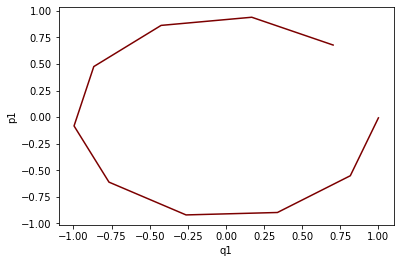

In [7]:
############################################################
#
# Comparison
#
############################################################

print("Random Walk Metropolis")
print("  Metropolis Accept Probability = " 
      + str(rwm_accept_prob_mean) + " +/- " + str(rwm_accept_prob_se))
print("  Average Effective Sample Size = " 
      + str(rwm_ave_eff_sample_size))
print("  Average Effective Sample Size Per Comp = " 
      + str(rwm_ave_eff_sample_size))
print("")
print("Hybrid Monte Carlo")
print("  Metropolis Accept Probability = " 
      + str(hybrid_accept_prob_mean) + " +/- " + str(hybrid_accept_prob_se))
print("  Average Effective Sample Size = " 
      + str(hybrid_ave_eff_sample_size))
print("  Average Effective Sample Size Per Comp = " 
      + str(hybrid_ave_eff_sample_size / L))
print("")
print("Static Multinomial Hamiltonian Monte Carlo")
print("  Proxy Metropolis Accept Probability = " 
      + str(smhmc_accept_prob_mean) + " +/- " + str(smhmc_accept_prob_se))
print("  Average Effective Sample Size = " 
      + str(smhmc_ave_eff_sample_size))
print("  Average Effective Sample Size Per Comp = " 
      + str(smhmc_ave_eff_sample_size / L))

# Why does Hybrid Monte Carlo perform so poorly here?  Bad tuning!
# The integration time is too long and the numerical trajectories
# end up back near the initial state, wasting the Hamiltonian flow.

q = numpy.asarray([1.0 for _ in range(D)])
p = numpy.asarray([stats.norm.rvs(0, 1) for _ in range(D) ])

Hs = [0] * (L + 1)
q1s = [0] * (L + 1)
p1s = [0] * (L + 1)

Hs[0] = hamiltonian(q, p)
q1s[0] = q[0]
p1s[0] = p[0]

for l in range(L):
  q, p = leapfrog(q, p, epsilon)
  Hs[l + 1] = hamiltonian(q, p)
  q1s[l + 1] = q[0]
  p1s[l + 1] = p[0]
  
plot.plot(q1s, p1s, color=dark_highlight)
plot.gca().set_xlabel("q1")
plot.gca().set_ylabel("p1")
plot.show()

# By multinomially sampling we utilize the entire numerial trajectory
# and become more robust to tuning.  The random forward and backwards
# evolution also sets up dynamic methods that automatically tune the
# integration time.